# 🔭 Notebook 2 — KNN & Decision Tree Classifiers
**Dataset:** Stellar Classification (SDSS)

This notebook covers:
1. K-Nearest Neighbors — hyperparameter sweep & evaluation
2. Decision Tree — GridSearchCV & tree visualization
3. Confusion matrices & classification reports for both models


## 0. Setup — Load Preprocessed Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from warnings import filterwarnings
filterwarnings('ignore')

with open('data/splits.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

with open('data/encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)

with open('data/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

class_names = encoder.classes_
print("Data loaded. Classes:", class_names)


Data loaded. Classes: ['GALAXY' 'QSO' 'STAR']


## 1. K-Nearest Neighbors (KNN)

### Principle
KNN predicts a class by **majority vote** among the K nearest neighbours
in the training set. Distance is computed using Euclidean (or other) metrics.

### Key hyperparameter: K
- **Odd values** are preferred to avoid ties.
- **Small K** → low bias, high variance (risk of overfitting).
- **Large K** → high bias, low variance (risk of underfitting).


### 1.1 Sweep K from 1 to 20 (odd values)

In [2]:
K_vals = list(range(1, 21, 2))
train_scores, test_scores, scores_dict = [], [], {}

start_knn = time.time()
for k in K_vals:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    tr = clf.score(X_train, y_train)
    te = clf.score(X_test,  y_test)
    train_scores.append(tr)
    test_scores.append(te)
    scores_dict[k] = [tr, te]
knn_time = time.time() - start_knn

print("k  | Train Acc | Test Acc")
for k, (tr, te) in scores_dict.items():
    print(f"{k:2d} |   {tr:.4f}  |  {te:.4f}")


k  | Train Acc | Test Acc
 1 |   1.0000  |  0.9278
 3 |   0.9583  |  0.9366
 5 |   0.9484  |  0.9331
 7 |   0.9431  |  0.9303
 9 |   0.9387  |  0.9285
11 |   0.9358  |  0.9280
13 |   0.9328  |  0.9270
15 |   0.9306  |  0.9252
17 |   0.9288  |  0.9242
19 |   0.9269  |  0.9229


### 1.2 Accuracy vs K

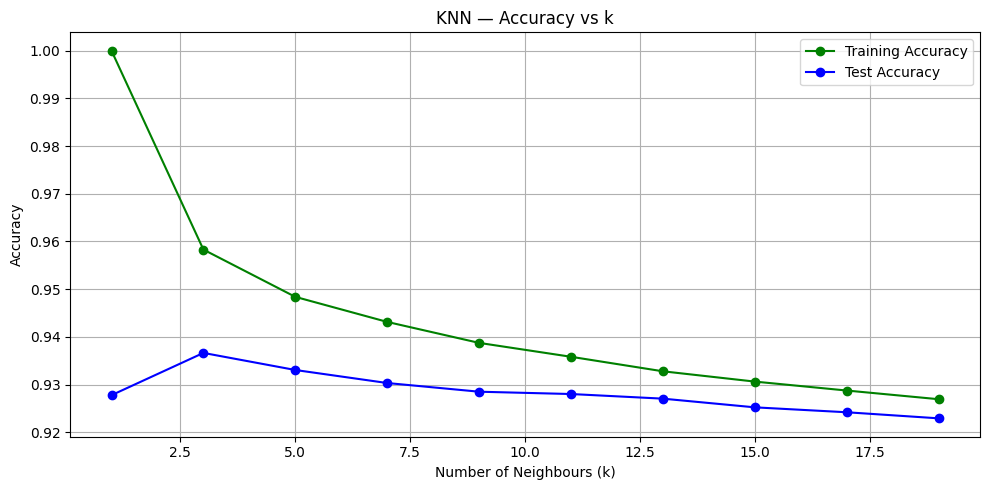

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(K_vals, train_scores, 'g-o', label='Training Accuracy')
plt.plot(K_vals, test_scores,  'b-o', label='Test Accuracy')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs k')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 1.3 Best K — Evaluation

In [4]:
best_k = K_vals[test_scores.index(max(test_scores))]
print(f"Best k: {best_k}  (Test Accuracy: {max(test_scores):.4f})")

clf_best = KNeighborsClassifier(n_neighbors=best_k)
clf_best.fit(X_train, y_train)
y_pred_knn = clf_best.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=class_names))


Best k: 3  (Test Accuracy: 0.9366)

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.90      0.92      0.91      5651
         QSO       0.97      0.93      0.95      5142
        STAR       0.94      0.96      0.95      5684

    accuracy                           0.94     16477
   macro avg       0.94      0.94      0.94     16477
weighted avg       0.94      0.94      0.94     16477



### 1.4 Confusion Matrix — KNN

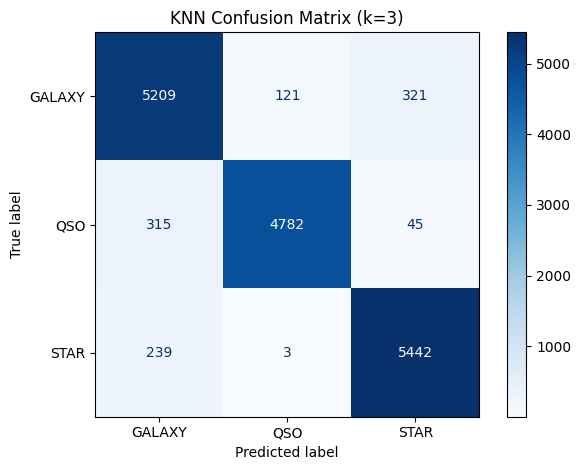

In [5]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title(f"KNN Confusion Matrix (k={best_k})")
plt.tight_layout()
plt.show()


## 2. Decision Tree Classifier

### Principle
A Decision Tree recursively **splits** the feature space into regions using
IF-THEN rules, minimising impurity (Gini or Entropy) at each node.

### Key hyperparameters
| Parameter | Effect |
|---|---|
| `max_depth` | Controls overfitting — lower depth = simpler model |
| `min_samples_split` | Minimum samples required to split a node |
| `min_samples_leaf` | Minimum samples in a leaf node |
| `criterion` | Split quality measure: `gini` or `entropy` |


### 2.1 GridSearchCV — Hyperparameter Tuning

In [6]:
param_grid_dt = {
    'criterion':         ['gini', 'entropy'],
    'max_depth':         [5, 10, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf':  [1, 2]
}

start_dt = time.time()
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5, n_jobs=-1, scoring='accuracy', verbose=1
)
dt_grid.fit(X_train, y_train)
dt_time = time.time() - start_dt

print("Best parameters:", dt_grid.best_params_)
print(f"Best CV accuracy: {dt_grid.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV accuracy: 0.9671


### 2.2 Evaluate Best Decision Tree

In [7]:
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.94      0.97      0.96      5651
         QSO       0.97      0.93      0.95      5142
        STAR       1.00      1.00      1.00      5684

    accuracy                           0.97     16477
   macro avg       0.97      0.97      0.97     16477
weighted avg       0.97      0.97      0.97     16477



### 2.3 Confusion Matrix — Decision Tree

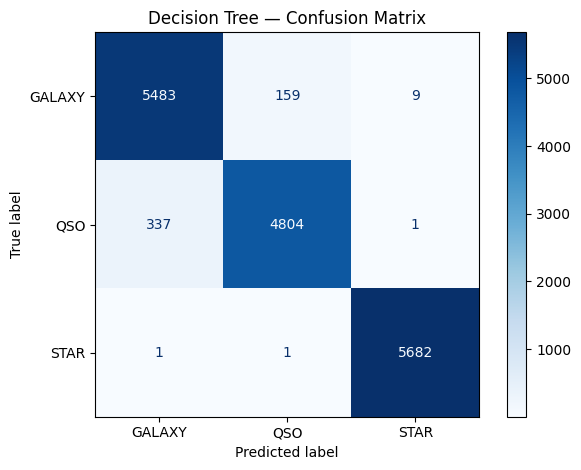

In [8]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=class_names)
disp_dt.plot(cmap='Blues', values_format='d')
plt.title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()


### 2.4 Visualise the Decision Tree

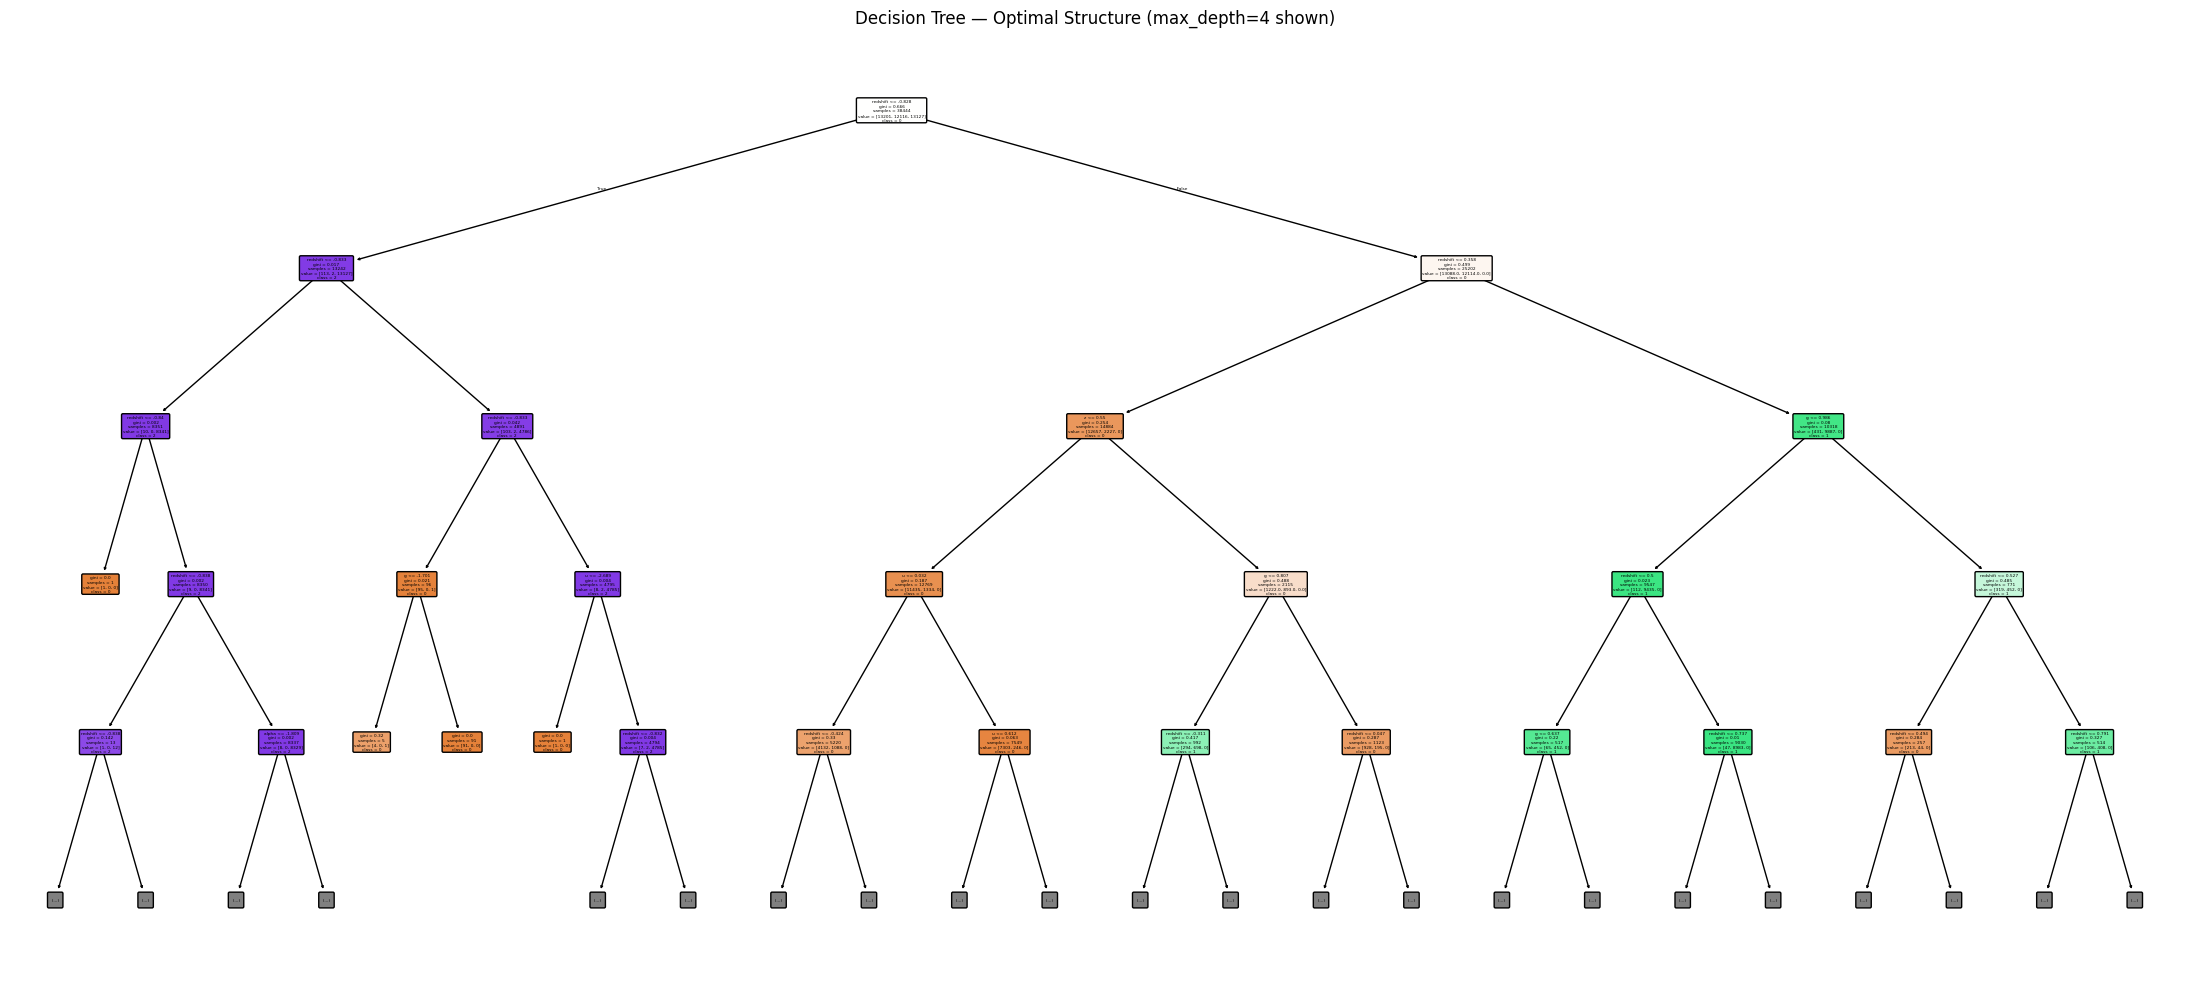

In [9]:
plt.figure(figsize=(22, 10))
plot_tree(
    best_dt,
    filled=True,
    feature_names=feature_names,
    class_names=best_dt.classes_.astype(str),
    rounded=True,
    max_depth=4  # Limit depth for readability
)
plt.title("Decision Tree — Optimal Structure (max_depth=4 shown)")
plt.tight_layout()
plt.show()


## 3. Save Predictions & Timing

In [10]:
import os, pickle
os.makedirs('predictions', exist_ok=True)
os.makedirs('models', exist_ok=True)

with open('predictions/knn_dt.pkl', 'wb') as f:
    pickle.dump({
        'y_pred_knn': y_pred_knn,
        'y_pred_dt':  y_pred_dt,
        'y_test':     y_test,
        'knn_time':   knn_time,
        'dt_time':    dt_time,
        'best_k':     best_k
    }, f)

with open('models/knn_best.pkl', 'wb') as f:
    pickle.dump(clf_best, f)

with open('models/dt_best.pkl', 'wb') as f:
    pickle.dump(best_dt, f)

print("Saved predictions and models.")
print(f"KNN training time : {knn_time:.2f}s")
print(f"DT  training time : {dt_time:.2f}s")


Saved predictions and models.
KNN training time : 23.33s
DT  training time : 29.42s
